In [49]:
import scanpy as sc
import matplotlib.pyplot as plt
from scipy import stats
import pandas
import scvelo as scv

In [41]:
adata = sc.read_h5ad('./data/scrna.h5ad')

In [44]:
adata_cd4 = adata[adata.obs['celltype_new'].str.startswith('CD4')].copy()
adata_cd8 = adata[adata.obs['celltype_new'].str.startswith('CD8')].copy()

In [45]:
# unbiased degs
adata_cd4_tmp = adata_cd4.copy()
sc.pp.filter_genes(adata_cd4_tmp, min_cells=0.05*adata_cd4_tmp.shape[0])
sc.pp.filter_genes(adata_cd4_tmp, max_cells=adata_cd4_tmp.shape[0]*0.9)
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('RPS')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('RPL')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('MT')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('MALAT1')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('XCL1')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.startswith('XIST')]
adata_cd4_tmp = adata_cd4_tmp[:, ~adata_cd4_tmp.var_names.str.contains(r'\.')]

sc.tl.rank_genes_groups(adata_cd4_tmp, 'celltype_new', method='wilcoxon')
sc.tl.filter_rank_genes_groups(adata_cd4_tmp, min_in_group_fraction=0.1, 
                               min_fold_change=0, max_out_group_fraction=0.5, compare_abs=True)
df_cd4_deg = sc.get.rank_genes_groups_df(adata_cd4_tmp, adata_cd4_tmp.obs['celltype_new'].unique(), 
                                         key='rank_genes_groups_filtered').dropna()

/data1/lesliec/sneha/anaconda/envs/sc-env/lib/python3.14/site-packages/scanpy/tools/_rank_genes_groups.py:829: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


In [46]:
df_cd4_deg_select = df_cd4_deg[(df_cd4_deg['logfoldchanges'] > 0.5) & (df_cd4_deg['pvals_adj'] < 1e-2)].sort_values(by=['group', 'logfoldchanges'],
                                                                                            ascending=False)
top10_cd4 = df_cd4_deg_select.groupby('group').head(250)
top10_cd4['names'].unique().shape

/tmp/ipykernel_3523885/2229120116.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top10_cd4 = df_cd4_deg_select.groupby('group').head(250)


(925,)

925 genes


[[<matplotlib.axis.YTick at 0x7f0cc98fce10>,
 [Text(1, 137.5, 'BCL2'),
  Text(1, 149.5, 'LEF1'),
  Text(1, 181.5, 'IL7R'),
  Text(1, 224.5, 'AHR'),
  Text(1, 228.5, 'SELL'),
  Text(1, 345.5, 'TRAC'),
  Text(1, 411.5, 'IL2RG'),
  Text(1, 760.5, 'GZMH'),
  Text(1, 767.5, 'HAVCR2'),
  Text(1, 778.5, 'PRF1'),
  Text(1, 783.5, 'TNFRSF14'),
  Text(1, 796.5, 'IFNG'),
  Text(1, 800.5, 'TOX'),
  Text(1, 810.5, 'TNFRSF9'),
  Text(1, 841.5, 'EOMES'),
  Text(1, 847.5, 'TIGIT'),
  Text(1, 857.5, 'CD27'),
  Text(1, 870.5, 'GZMK'),
  Text(1, 904.5, 'NKG7'),
  Text(1, 907.5, 'GZMA')]]

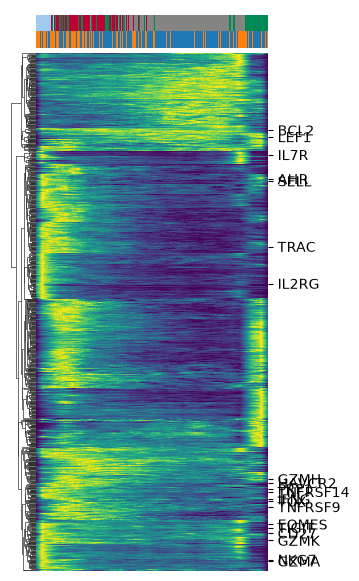

In [57]:
genes = top10_cd4['names'].unique().tolist()
highlight_genes = ['BCL2', 'LEF1', 'IL7R', 'AHR', 'SELL', 'TRAC', 'IL2RG', 'GZMH', 'HAVCR2', 
                   'PRF1', 'TNFRSF14', 'IFNG', 'TOX', 'TNFRSF9', 'EOMES',  'TIGIT', 'CD27', 'GZMK',
                   'NKG7', 'GZMA', 'IZKF2']
highlight_genes = list(filter(lambda x: x in genes, highlight_genes))

adata_tmp = adata_cd4.copy()
sc.pp.filter_genes(adata_tmp, min_cells=0.05*adata_tmp.shape[0])
genes = adata_tmp.var_names[adata_tmp.var_names.isin(genes)]
print(len(genes), "genes")
highlight_genes = list(filter(lambda x: x in genes, highlight_genes))

g = scv.pl.heatmap(adata_cd4[adata_cd4.obsm['branch_masks_CD4'][adata_cd4.obsm['branch_masks_CD4'].columns[0]]], 
                   var_names=genes, rasterized=True,
                   tkey='palantir_pseudotime_cd4', n_convolve=500, col_color=['celltype_new', 'car'],
                   metric='euclidean', row_cluster=True, 
               standard_scale=0, show=False, yticklabels=True,
              figsize=(4, 6))


reordered_labels = g.data.index.tolist()
use_ticks = [reordered_labels.index(label) + .5 for label in highlight_genes]
g.ax_heatmap.set(yticks=use_ticks, yticklabels=highlight_genes)

In [58]:
# unbiased degs
adata_cd8_tmp = adata_cd8.copy()
sc.pp.filter_genes(adata_cd8_tmp, min_cells=0.05*adata_cd8_tmp.shape[0])
sc.pp.filter_genes(adata_cd8_tmp, max_cells=adata_cd8_tmp.shape[0]*0.9)
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('RPS')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('RPL')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('MT')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('MALAT1')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('XCL1')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.startswith('XIST')]
adata_cd8_tmp = adata_cd8_tmp[:, ~adata_cd8_tmp.var_names.str.contains(r'\.')]

sc.tl.rank_genes_groups(adata_cd8_tmp, 'celltype_new', method='wilcoxon')
sc.tl.filter_rank_genes_groups(adata_cd8_tmp, min_in_group_fraction=0.1, 
                               min_fold_change=0, max_out_group_fraction=0.5, compare_abs=True)
df_cd8_deg = sc.get.rank_genes_groups_df(adata_cd8_tmp, adata_cd8_tmp.obs['celltype_new'].unique(), 
                                         key='rank_genes_groups_filtered').dropna()

In [59]:
df_cd8_deg_select = df_cd8_deg[(df_cd8_deg['logfoldchanges'] > 0.5) & (df_cd8_deg['pvals_adj'] < 1e-2)].sort_values(by=['group', 'logfoldchanges'],
                                                                                            ascending=False)
top10_cd8 = df_cd8_deg_select.groupby('group').head(250)
top10_cd8['names'].unique().shape

(1084,)

1084 genes


[[<matplotlib.axis.YTick at 0x7f0cbb116fd0>,
 [Text(1, 65.5, 'MKI67'),
  Text(1, 124.5, 'IKZF2'),
  Text(1, 261.5, 'BCL2'),
  Text(1, 322.5, 'PRF1'),
  Text(1, 338.5, 'TRAC'),
  Text(1, 400.5, 'CD27'),
  Text(1, 416.5, 'EOMES'),
  Text(1, 418.5, 'TIGIT'),
  Text(1, 421.5, 'GZMK'),
  Text(1, 427.5, 'SELL'),
  Text(1, 441.5, 'CTLA4'),
  Text(1, 462.5, 'IL7R'),
  Text(1, 488.5, 'CD28'),
  Text(1, 946.5, 'CCL3'),
  Text(1, 950.5, 'HAVCR2'),
  Text(1, 1052.5, 'TNFRSF9'),
  Text(1, 1056.5, 'TOX'),
  Text(1, 1082.5, 'ICOS')]]

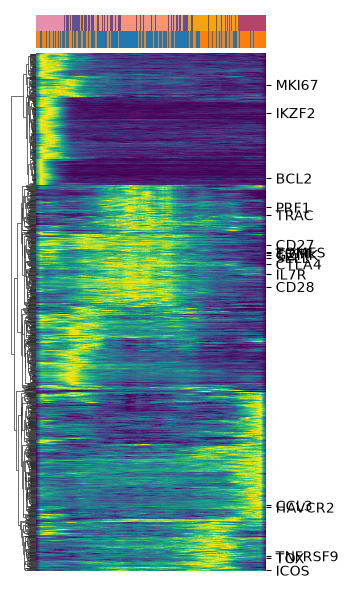

In [63]:
genes = top10_cd8['names'].unique().tolist()
highlight_genes = ['MKI67', 'IKZF2', 'BCL2', 'PRF1', 'TRAC', 'CD27', 'EOMES', 'TIGIT', 
                   'GZMK', 'SELL', 'CTLA4', 'IL7R', 'CD28', 'CCL3', 'HAVCR2', 'TNFRSF9', 'TOX', 'ICOS']
highlight_genes = list(filter(lambda x: x in genes, highlight_genes))

adata_tmp = adata_cd8.copy()
sc.pp.filter_genes(adata_tmp, min_cells=0.05*adata_tmp.shape[0])
genes = adata_tmp.var_names[adata_tmp.var_names.isin(genes)]
print(len(genes), "genes")
highlight_genes = list(filter(lambda x: x in genes, highlight_genes))

g = scv.pl.heatmap(adata_cd8[adata_cd8.obsm['branch_masks_CD8'][adata_cd8.obsm['branch_masks_CD8'].columns[0]]], 
                   var_names=genes, rasterized=True,
                   tkey='palantir_pseudotime_cd8', n_convolve=500, col_color=['celltype_new', 'car'],
                   metric='euclidean', row_cluster=True, 
               standard_scale=0, show=False, yticklabels=True,
              figsize=(4, 6))


reordered_labels = g.data.index.tolist()
use_ticks = [reordered_labels.index(label) + .5 for label in highlight_genes]
g.ax_heatmap.set(yticks=use_ticks, yticklabels=highlight_genes)

In [64]:
genes = {'TFs': ['TCF7', 'LEF1', 'TBX21', 'EOMES', 'BACH2', 'PRDM1', 'TOX'],
         'Surface': ['CD27', 'CD28', 'IL7R', 'PDCD1', 'HAVCR2'],
         'Function': ['PRF1', 'GZMA', 'GZMB', 'GZMK', 'NKG7', 'GNLY', 'IFNG'],
         'Treg': ['FOXP3', 'IKZF2', 'CTLA4'],
         'Prolif': ['TOP2A', 'CDK1', 'MKI67']}

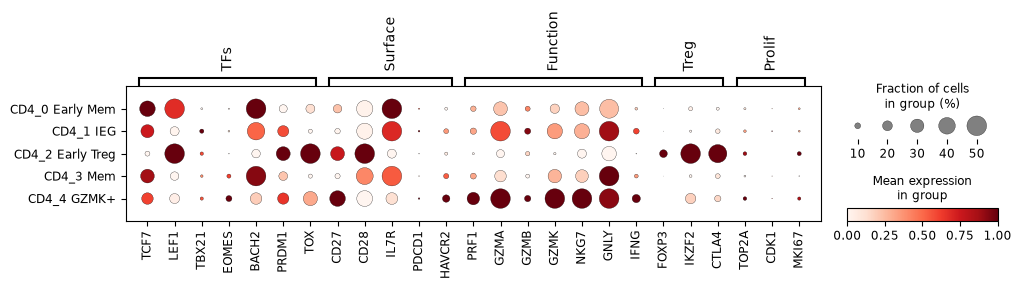

In [66]:
sc.pl.dotplot(adata_cd4, genes, groupby='celltype_new', dot_max=0.5, standard_scale='var')

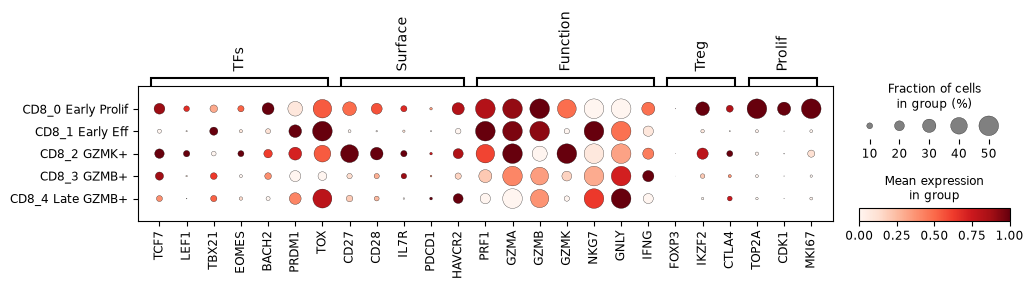

In [67]:
sc.pl.dotplot(adata_cd8, genes, groupby='celltype_new', dot_max=0.5, standard_scale='var')